![Py4Eng](../logo.png)

# Density Estimation with Normalizing Flows
## Yoav Ram

In this session we will understand:
- what density estimation is, and why it is harder than it looks
- how the classical baselines -- kernel density estimation and Gaussian mixtures -- work, and where they break down
- how a normalizing flow turns a simple base distribution into a complicated one through an invertible map
- how masking gives a *triangular* Jacobian and monotonicity gives *invertibility* -- two separate guarantees, which we check numerically rather than assert
- how to train a masked autoregressive flow with FlowJAX and read its log-likelihood
- how the three model families compare on a toy 2D dataset and on a real six-dimensional benchmark

This is the one session that uses [FlowJAX](https://danielward27.github.io/flowjax/) rather than Keras.
There is no Keras normalizing-flow implementation worth teaching, and flows are built out of invertible bijections rather than layers, so the API looks different on purpose.
FlowJAX is built on JAX, so everything here runs on the same accelerator as the rest of the course.

Density estimation asks for a model of an unknown distribution $p(x)$ given only samples from it.
Unlike classification or regression there is no label to predict -- the density *is* the answer.

We work through two datasets:

1. **`make_moons`**, a 2D toy: fit KDE and a GMM, see why they struggle with curved support, then train a masked autoregressive flow (MAF) and compare densities and samples.
2. **UCI POWER**, a six-dimensional benchmark: fit the same four models and compare test log-likelihoods in nats.


In [1]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity

import jax
import jax.numpy as jnp
from jax import random
import flowjax
import flowjax.bijections
import flowjax.distributions
import flowjax.flows
import flowjax.masks
import flowjax.train

sns.set(style='white', context='talk')
SEED = 130
print('JAX:', jax.__version__, 'backend:', jax.default_backend())
print('FlowJAX:', flowjax.__version__)

JAX: 0.11.1 backend: gpu
FlowJAX: 19.1.1


In [2]:
# Some utility functions for plotting and data manipulation
def make_grid(data, pad=0.6, n=220):
    lower = data.min(axis=0) - pad
    upper = data.max(axis=0) + pad
    xs = np.linspace(lower[0], upper[0], n)
    ys = np.linspace(lower[1], upper[1], n)
    xx, yy = np.meshgrid(xs, ys)
    grid = np.column_stack([xx.ravel(), yy.ravel()]).astype(np.float32)
    return xs, ys, grid, lower, upper

def plot_density(xs, ys, log_density, data=None, title="", cmap="viridis", ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    density = np.exp(np.asarray(log_density)).reshape(len(ys), len(xs))
    ax.contourf(xs, ys, density, levels=30, cmap=cmap)
    ax.set_title(title)
    if data is not None:
        ax.scatter(data[:, 0], data[:, 1], s=4, c="white", alpha=0.18, edgecolors="none")

def plot_samples(samples, title="", ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax.scatter(samples[:, 0], samples[:, 1], s=6, c="black", alpha=0.5, edgecolors="none")
    ax.set_title(title)

def clip_to_window(samples, lower, upper):
    mask = np.all((samples >= lower) & (samples <= upper), axis=1)
    return samples[mask]



## Two-moons dataset

The two-moons dataset is useful because the true distribution is clearly non-Gaussian and lies on a curved manifold.
That makes it a good stress test for density models with different inductive biases.


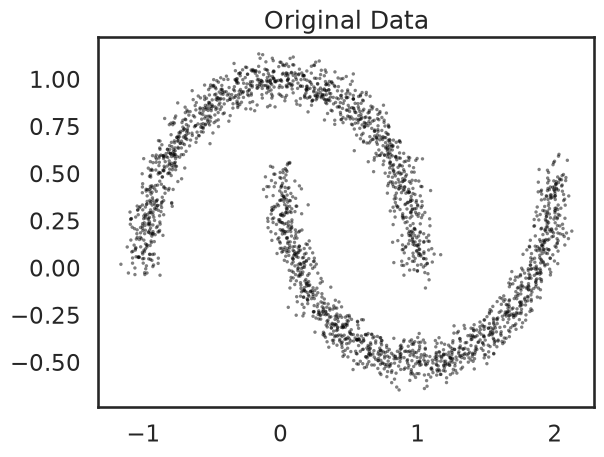

In [3]:

X, labels = make_moons(n_samples=2500, noise=0.06, random_state=0)
X = X.astype(np.float32)
xs, ys, grid, lower, upper = make_grid(X)

# A second, independent draw from the same generator, held out.
# `fit_to_data` carves its own validation split out of X, so without this we
# would have no honest number to quote for a model we have not tuned on.
X_moons_test, _ = make_moons(n_samples=2500, noise=0.06, random_state=1)
X_moons_test = X_moons_test.astype(np.float32)

plot_samples(X, title="Original Data")


## Compact Baselines: KDE and GMM

We keep two classical baselines:

1. **KDE** is flexible and local, but its smoothness is controlled by a bandwidth parameter.
2. **GMM** is parametric and easy to sample from, but it prefers elliptic clusters.

Both models are useful reference points before we train a flow model.

### KDE 
In Kernel density estimation, we put one Gaussian of a specific width (hyper parameter) over each data point, and then sum the Gaussians together to get the full density estimate.


In [4]:
kde = KernelDensity(kernel="gaussian", bandwidth=0.18)
kde.fit(X)
kde_log_density = kde.score_samples(grid)
kde_samples = kde.sample(1000)

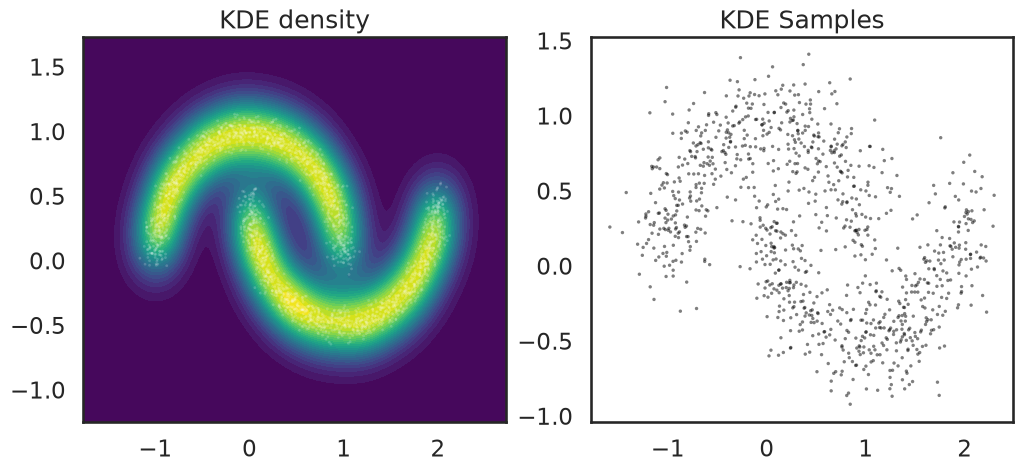

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_density(xs, ys, kde_log_density, data=X, title="KDE density", ax=ax[0])
plot_samples(kde_samples, title="KDE Samples", ax=ax[1])


### Gaussian mixed models

In GMM, we assume a mixture model (a type of a hierarchical model), here shown for a mixture of two Gaussians:
$$
x_i \sim \begin{cases}
    N(\mu_1, \rho_1), & z_i=0 \\
    N(\mu_2, \rho_2), & z_i=1 \\
\end{cases}
$$
where $z_i$ is a latent random variable that controls the mixture:
$$
z_i \sim \mathit{Bernoulli}(p)
$$
That is, $x_i$ is distributed according to $N(\mu_1, \rho_1)$ with probability $p$ and according to $N(\mu_2, \rho_2)$ with probability $1-p$.

In [6]:
gmm = GaussianMixture(n_components=8, covariance_type="full", random_state=0)
gmm.fit(X)
gmm_log_density = gmm.score_samples(grid)
gmm_samples = gmm.sample(1000)[0]

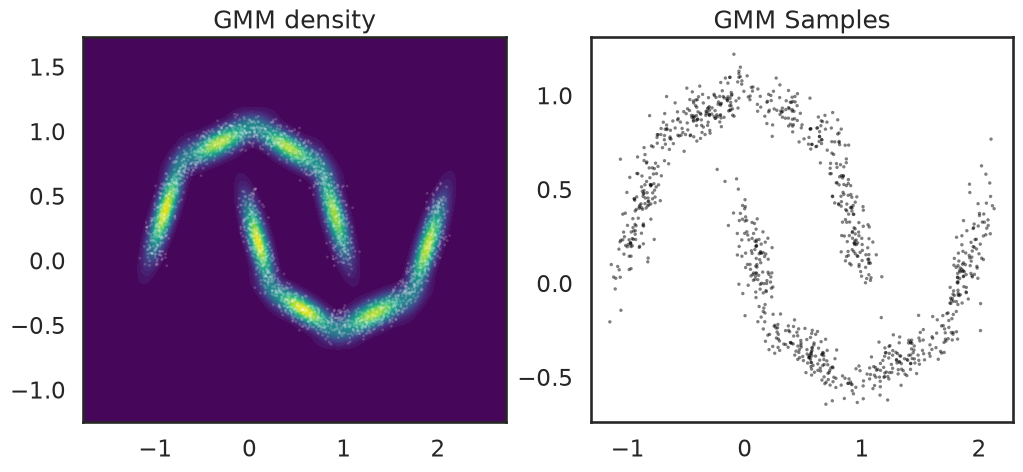

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_density(xs, ys, gmm_log_density, data=X, title="GMM density", ax=ax[0])
plot_samples(gmm_samples, title="GMM Samples", ax=ax[1])


The KDE tracks the moons reasonably well, but has no global latent representation and can oversmooth or leak mass between nearby regions.

The GMM is efficient and interpretable, but a small number of Gaussian components cannot bend naturally around the two crescents.

This is the point where normalizing flows become interesting: they keep **sampling** and **density evaluation**, but with a much more flexible geometry.


## Normalizing Flows

A normalizing flow is built from two pieces that play very different roles, and it's worth keeping them separate in your head:

- The base distribution $p_Z$: a fixed, simple distribution we can sample from and evaluate exactly, in many cases a standard multivariate Gaussian, 
$$
z_i \sim \mathcal{N}(0, I)
$$
- The map $f_{\theta}$ — a learned (with parameters $\theta$), *invertible* function that warps $z$ into the data space,
$$
x_i = f_{\theta}(z_i) \\
z_i = f_{\theta}^{-1}(x_i)
$$

$p_Z$ never changes; all of the flexibility needed to fit a complicated, curved data density is in $f$.

Because $f_{\theta}$ is invertible, we can both sample $x$:
$$
z_i \sim \mathcal{N}(0, I) \\ 
x_i = f_{\theta}(z_i)
$$
as well as evaluate exact density using the [change-of-variables formula](https://en.wikipedia.org/wiki/Probability_density_function#Vector_to_vector):
$$
p_X(x_i \mid \theta) = p_Z(f_{\theta}^{-1}(x_i)) \cdot \left|\det J_{f_{\theta}^{-1}}(x_i)\right|
$$

So designing a flow means designing $f_{\theta}$: it has to be 
1. expressive enough to capture the data, 
1. invertible, and 
1. have a Jacobian determinant that's cheap to compute.

Those three demands pull against each other — the usual way to make a function more expressive is to make it harder to invert — and the flow we use here meets them with two **independent** choices:

| choice | what it fixes | what we use |
|---|---|---|
| the **structure** | which inputs each output is allowed to depend on | masked autoregressive (MADE) |
| the **transformer** | the scalar function applied per dimension | affine here, a spline on POWER |

Nearly every flow in the literature is some pair of these two, so it pays to name them separately and to keep track of which one you are changing.

### The structure: autoregressive conditioning, and MADE

Any density factorizes by the chain rule, with no assumptions at all:
$$
p_X(x) = \prod_{j=1}^{D} p(x_j \mid x_{<j}) .
$$

An **autoregressive** flow turns that factorization into a map. Output dimension $j$ is produced from $z_j$ by a scalar function $\tau$ whose *parameters* are computed from the earlier **data** coordinates:
$$
x_j = \tau\big(z_j;\ \theta_j(x_{<j})\big) .
$$

The two arguments do completely different jobs, and the whole design is in the split:

- $\theta_j$ is the **conditioner** — a neural network. It sees strictly $x_{<j}$, that is coordinates $1, \dots, j-1$. It never sees $x_j$ itself.
- $\tau$ is the **transformer** — a scalar invertible function of $z_j$ alone, with the conditioner's output as its parameters. Dimension $j$ enters *only* here.

That restriction is not cosmetic. Since $\theta_j$ cannot see $x_j$ or anything later, $x_j$ cannot depend on $z_k$ for $k > j$, so the Jacobian $\partial x/\partial z$ is **lower triangular**. A triangular determinant is just the product of the diagonal, so $\log|\det J|$ costs $O(D)$ instead of the $O(D^3)$ of a general determinant — at any dimension. That is requirement 3, solved. Let the conditioner peek at $x_j$ and the triangularity, and with it the cheap determinant, is gone.

#### MADE: all $D$ conditioners out of one network

Taken literally the recipe needs $D$ separate conditioner networks, the $j$-th seeing only $x_{<j}$: $D$ sets of parameters and $D$ forward passes. **MADE** ([Germain, Gregor, Murray & Larochelle, 2015](https://arxiv.org/abs/1502.03509)) gets all $D$ of them out of a *single* MLP, by zeroing weights:

- give every hidden unit a **degree** $m \in \{1, \dots, D-1\}$;
- connect input $i \to$ hidden unit iff $i \le m$;
- connect hidden unit $\to$ output $j$ iff $m < j$.

Compose the two rules: a path from input $i$ to output $j$ has to pass through some hidden unit with $i \le m < j$, which is possible only when $i < j$. So there is no path at all from input $j$ to output $j$, or to any output after it. The autoregressive property is enforced by the *architecture*, not by a penalty or a training trick, and it costs one forward pass instead of $D$.

The "autoencoder" in the name is historical: MADE was introduced as a masked autoencoder that happened to do density estimation. Here it plays exactly one role — it is the conditioner.

### The transformer: affine, and the two guarantees

The transformer $\tau$ is a *separate* choice from the structure, and the simplest useful one is **affine**:
$$
x_j = z_j\, e^{s_j} + t_j , \qquad (s_j, t_j) = \theta_j(x_{<j}) ,
$$
with MADE producing the pair $(s_j, t_j)$ for every dimension at once. Writing the scale as $e^{s_j}$ rather than as a raw number is the trick, and two lines finish the argument:

$$
\frac{\partial x_j}{\partial z_j} = e^{s_j} > 0
\quad\Longrightarrow\quad
\tau \text{ is strictly increasing in } z_j, \text{ hence invertible,}
$$

$$
\log\left|\det J_f\right| \;=\; \sum_{j=1}^{D} \log e^{s_j} \;=\; \sum_{j=1}^{D} s_j .
$$

These are **two separate guarantees**, bought from two different places, and blurring them is the single most common way to misunderstand a flow:

| guarantee | comes from | what it buys |
|---|---|---|
| $J$ is triangular | the **masking** (MADE) | a determinant that costs $O(D)$ |
| $f$ is invertible | the transformer being strictly **monotone** | an $f^{-1}$, hence a density at all |

Masking on its own does *not* make $f$ invertible — a triangular matrix with a zero on the diagonal is perfectly triangular and perfectly singular. Monotonicity on its own does not make the determinant cheap. You need both, and neither implies the other.

**Naming.** "MAF" in [Papamakarios, Pavlakou & Murray (2017)](https://arxiv.org/abs/1705.07057) means this structure *with an affine transformer*. That is exactly what we fit to the two moons below. On POWER we keep the structure and swap the transformer for a more flexible one — still a masked autoregressive flow, no longer a MAF in the paper's sense.

**One direction is cheap and the other is not.** FlowJAX's `masked_autoregressive_flow` defaults to `invert=True`, which points the fast direction at density evaluation: `log_prob` is a **single** pass, because all of $x$ is given at once and all $D$ conditioners fire in parallel. Sampling is the opposite — $x_1$ must exist before $\theta_2$ can be computed, $x_2$ before $\theta_3$, and so on — so it costs $D$ **sequential** passes. This is why the flow will score 204,928 six-dimensional points in about eight seconds while drawing samples is relatively slow, and it is the whole reason *coupling* flows (RealNVP, Glow) exist: they give up expressiveness per layer to make both directions a single pass.

The model is implemented in [FlowJAX](https://danielward27.github.io/flowjax/), a JAX package for continuous distributions, bijections and normalizing flows.

### Checking the claims: one dimension first

Everything above was asserted. Before we build a flow, let us verify the change-of-variables formula in the one case where the "Jacobian determinant" is a single derivative and every piece can be drawn.

Take a fixed, hand-chosen monotone map — no learning, no network:
$$
f(z) = z + \tfrac{3}{2}\tanh(z) ,
\qquad
f'(z) = 1 + \tfrac{3}{2}\,\operatorname{sech}^2(z) \;\ge\; 1 \;>\; 0 ,
$$
so $f$ is strictly increasing and therefore invertible. Push $z \sim \mathcal{N}(0,1)$ through it and the density of $x = f(z)$ is predicted exactly:
$$
p_X(x) = p_Z\big(f^{-1}(x)\big)\,\big|(f^{-1})'(x)\big|
       = \frac{p_Z\big(f^{-1}(x)\big)}{f'\big(f^{-1}(x)\big)} ,
$$
the second form by the inverse function theorem, which saves us from differentiating $f^{-1}$.

There is no closed form for $f^{-1}$ here, so we invert numerically by bisection. That is worth noticing: *invertible* is a property of the function, not a promise of a formula.

round trip  max |f^-1(f(z)) - z| = 9.54e-07


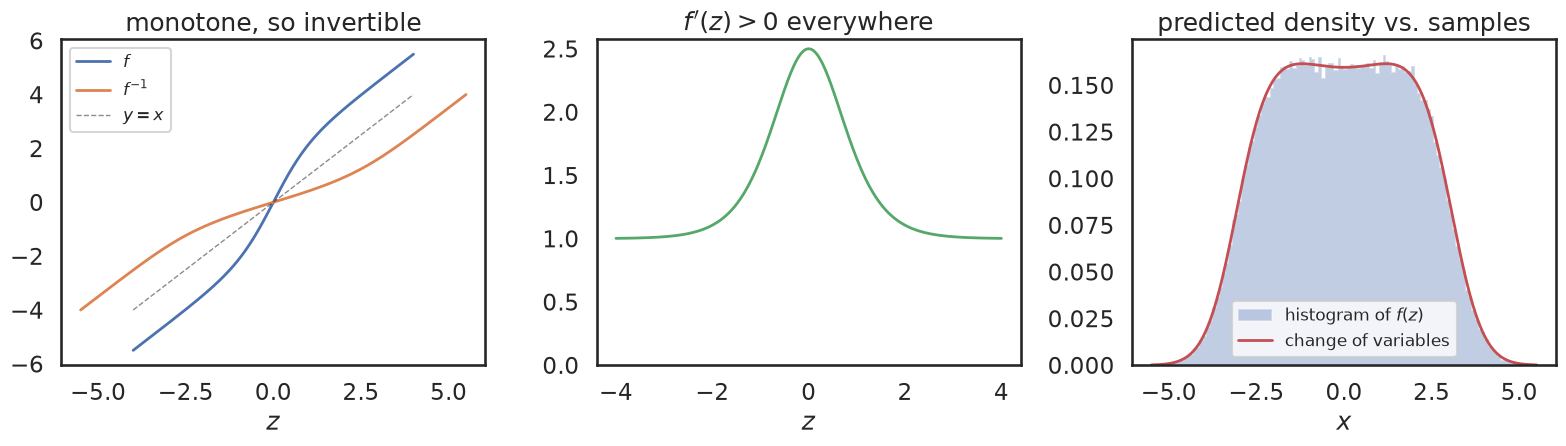

In [8]:
f  = lambda z: z + 1.5 * jnp.tanh(z)
df = jax.grad(f)

def f_inverse(x, lo=-12.0, hi=12.0, steps=60):
    """f is strictly increasing, so plain bisection inverts it to machine precision."""
    lo, hi = jnp.full_like(x, lo), jnp.full_like(x, hi)
    for _ in range(steps):
        mid = 0.5 * (lo + hi)
        high = jax.vmap(f)(mid) > x
        hi, lo = jnp.where(high, mid, hi), jnp.where(high, lo, mid)
    return 0.5 * (lo + hi)

zz = jnp.linspace(-4, 4, 400)
xx = jnp.linspace(-5.5, 5.5, 400)

z_of_x = f_inverse(xx)
p_x = jnp.exp(jax.scipy.stats.norm.logpdf(z_of_x)) / jax.vmap(df)(z_of_x)  # change of variables

key = random.key(SEED)
key, subkey = random.split(key)
z_samples = random.normal(subkey, (200_000,))
x_samples = jax.vmap(f)(z_samples)

print(f'round trip  max |f^-1(f(z)) - z| = {jnp.max(jnp.abs(f_inverse(jax.vmap(f)(zz)) - zz)):.2e}')

fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
ax[0].plot(zz, jax.vmap(f)(zz), lw=2, label='$f$')
ax[0].plot(jax.vmap(f)(zz), zz, lw=2, label='$f^{-1}$')
ax[0].plot(zz, zz, 'k--', lw=1, alpha=0.5, label='$y=x$')
ax[0].set(title='monotone, so invertible', xlabel='$z$')
ax[0].legend(fontsize=12)

ax[1].plot(zz, jax.vmap(df)(zz), lw=2, color='C2')
ax[1].set(title="$f'(z) > 0$ everywhere", xlabel='$z$', ylim=(0, None))

ax[2].hist(np.asarray(x_samples), bins=120, range=(-5.5, 5.5), density=True,
           histtype='stepfilled', alpha=0.35, label='histogram of $f(z)$')
ax[2].plot(xx, p_x, lw=2, color='C3', label='change of variables')
ax[2].set(title='predicted density vs. samples', xlabel='$x$')
ax[2].legend(fontsize=12)
fig.tight_layout()

The red curve was never fitted to anything: it is $p_Z$ divided by $f'$, evaluated at $f^{-1}(x)$.
It lands on the histogram because the change-of-variables formula is an identity, not an approximation.

Look at what one monotone squeeze did to a standard Gaussian -- it is now flat-topped and nearly bimodal.
That is the entire idea of a flow, and the rest of this section is about doing it in $D$ dimensions without paying $O(D^3)$ for the determinant.

### Checking the claims: the masks and the Jacobian

Now the two structural claims: that MADE's masks give a strictly triangular *conditioner*, and that the transformer is what fills in the diagonal.

We use $D = 6$ (the dimension of the POWER data later) and a deliberately narrow hidden layer so the masks fit on a screen.
`flowjax.masks.rank_based_mask` is FlowJAX's own mask builder -- these are the actual matrices the library multiplies its weights by, not an illustration of them.

paths from input i to output j:
 [[ 0  0  0  0  0  0]
 [ 3  0  0  0  0  0]
 [ 6  3  0  0  0  0]
 [ 8  5  2  0  0  0]
 [10  7  4  2  0  0]
 [12  9  6  4  2  0]]

conditioner: strictly lower triangular? True
full layer : anything above the diagonal? 0.0e+00
full layer : the diagonal is              [1.189 1.21  1.041 0.861 1.078 0.869]


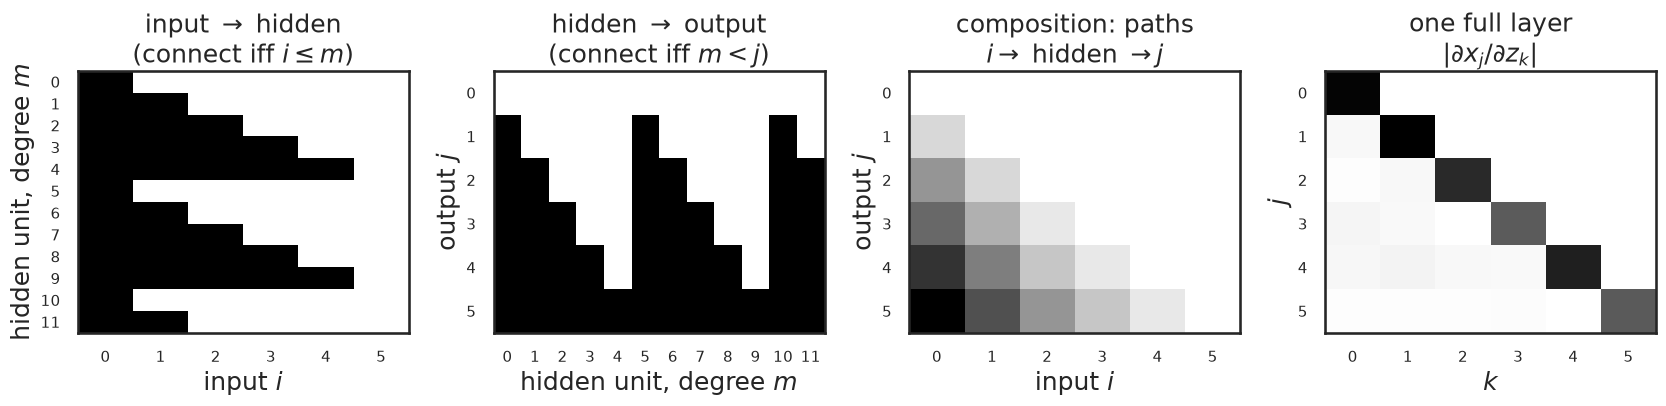

In [9]:
D, WIDTH = 6, 12

# MADE degrees, assigned exactly as FlowJAX assigns them.
input_degrees  = jnp.arange(D)                # 0 .. D-1, one per input coordinate
hidden_degrees = jnp.arange(WIDTH) % (D - 1)  # 0 .. D-2, cycled over the hidden units
output_degrees = jnp.arange(D)                # one row per output dimension

# eq=True  -> connect iff  i <= m   (input to hidden)
# eq=False -> connect iff  m <  j   (hidden to output)
mask_in  = np.asarray(flowjax.masks.rank_based_mask(input_degrees, hidden_degrees, eq=True)).astype(int)
mask_out = np.asarray(flowjax.masks.rank_based_mask(hidden_degrees, output_degrees, eq=False)).astype(int)
paths = mask_out @ mask_in    # how many input_i -> hidden -> output_j paths survive

# ... and one real FlowJAX autoregressive layer, differentiated numerically.
key, subkey = random.split(key)
made_layer = flowjax.bijections.MaskedAutoregressive(
    subkey, transformer=flowjax.bijections.Affine(), dim=D, nn_width=WIDTH, nn_depth=1)
key, subkey = random.split(key)
J = np.asarray(jax.jacfwd(made_layer.transform)(random.normal(subkey, (D,))))

print('paths from input i to output j:\n', paths)
print('\nconditioner: strictly lower triangular?', bool(np.all(np.triu(paths) == 0)))
print('full layer : anything above the diagonal?', f'{np.abs(np.triu(J, 1)).max():.1e}')
print('full layer : the diagonal is             ', np.round(np.diag(J), 3))

fig, axes = plt.subplots(1, 4, figsize=(17, 4.4))
for ax, M, title, xlabel, ylabel in [
    (axes[0], mask_in,  'input $\\to$ hidden\n(connect iff $i \\leq m$)', 'input $i$', 'hidden unit, degree $m$'),
    (axes[1], mask_out, 'hidden $\\to$ output\n(connect iff $m < j$)', 'hidden unit, degree $m$', 'output $j$'),
    (axes[2], paths,    'composition: paths\n$i \\to$ hidden $\\to j$', 'input $i$', 'output $j$'),
    (axes[3], np.abs(J),'one full layer\n$|\\partial x_j / \\partial z_k|$', '$k$', '$j$'),
]:
    ax.imshow(M, cmap='Greys', vmin=0, aspect='auto')
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel,
           xticks=range(M.shape[1]), yticks=range(M.shape[0]))
    ax.tick_params(labelsize=11)
fig.tight_layout()

Read the third and fourth panels side by side -- they are the entire argument.

**Panel 3** is the conditioner's dependency pattern, and it is *strictly* lower triangular: the diagonal is white.
Output $j$'s transformer parameters $(s_j, t_j)$ genuinely do not see $x_j$. Nothing was trained to make that true; it follows from composing the two masks.

**Panel 4** is the Jacobian of a whole layer, and it is lower triangular *with a dark diagonal*.
The diagonal appeared because of the transformer: $\partial x_j/\partial z_j = e^{s_j}$, which is where invertibility comes from, and it is the only entry the log-determinant needs.
Masking hollowed out the upper triangle; the transformer filled the diagonal. Two guarantees, two mechanisms, visible separately.

One honest caveat. A *stack* of these layers is not triangular, because FlowJAX permutes the coordinates between layers -- otherwise dimension $1$ would never be conditioned on anything at all, in any layer. That costs nothing: the log-determinant of a composition is the sum of the per-layer log-determinants, and each of those is still a cheap triangular one.

### Optional: one autoregressive layer, written out by hand

**This section can be skipped if you are short on time** -- nothing later in the notebook depends on it.
It exists because a flow layer is small enough to write out completely, and seeing it in twenty lines of JAX removes any remaining magic from the library call in the next cell.

Take $D = 2$. The first dimension has no predecessors, so its transformer parameters are just free scalars; the second gets its parameters from a small network of $x_1$:

$$
x_1 = z_1 e^{s_1} + t_1 ,
\qquad
x_2 = z_2\, e^{s(x_1)} + t(x_1) .
$$

The Jacobian follows by inspection. $x_1$ does not involve $z_2$ at all, so the top-right entry is exactly zero:

$$
J \;=\; \frac{\partial x}{\partial z} \;=\;
\begin{pmatrix}
e^{s_1} & 0 \\[4pt]
\dfrac{\partial x_2}{\partial z_1} & e^{s(x_1)}
\end{pmatrix} ,
\qquad
\det J = e^{s_1} \cdot e^{s(x_1)} ,
\qquad
\log|\det J| = s_1 + s(x_1) .
$$

The bottom-left entry is some messy expression involving $s'$ and $t'$ -- and we never have to compute it, which is the point of triangularity.

Inverting is sequential, and in $D=2$ that means two steps: recover $z_1$ from $x_1$, then use $x_1$ to rebuild the parameters that produced $x_2$.

$$
z_1 = (x_1 - t_1)e^{-s_1} ,
\qquad
z_2 = \big(x_2 - t(x_1)\big)\,e^{-s(x_1)} .
$$

A useful coincidence: in $D = 2$ this is also a *coupling* layer (RealNVP's building block) composed with an elementwise affine map, because "all the coordinates before $j$" and "the first half of the coordinates" are the same set. In higher dimensions they part ways, which is why the two families are different -- but here we can stay inside masked-autoregressive vocabulary.

In [10]:
params = dict(s1=0.4, t1=-0.3, w=jnp.array([0.8, -0.5]), b=jnp.array([0.2, 0.1]))

def conditioner(x1, p):
    """The whole conditioner for D=2: (s, t) for dimension 2, from dimension 1 alone."""
    h = jnp.tanh(p['w'] * x1 + p['b'])
    return h[0], h[1]

def layer(z, p):
    x1 = z[0] * jnp.exp(p['s1']) + p['t1']       # no predecessors: free parameters
    s2, t2 = conditioner(x1, p)                  # dimension 2 is conditioned on x1
    x2 = z[1] * jnp.exp(s2) + t2
    return jnp.stack([x1, x2])

def layer_inverse(x, p):
    z1 = (x[0] - p['t1']) * jnp.exp(-p['s1'])    # step 1: recover z1 from x1
    s2, t2 = conditioner(x[0], p)                # x1 is known, so the parameters are too
    z2 = (x[1] - t2) * jnp.exp(-s2)              # step 2: recover z2
    return jnp.stack([z1, z2])

def layer_log_det(z, p):
    """Sum of the diagonal, by hand. Never touches the lower-left entry."""
    x1 = z[0] * jnp.exp(p['s1']) + p['t1']
    s2, _ = conditioner(x1, p)
    return p['s1'] + s2

key, subkey = random.split(key)
z = random.normal(subkey, (2,))

print('round trip  max |f^-1(f(z)) - z| =',
      f'{jnp.max(jnp.abs(layer_inverse(layer(z, params), params) - z)):.2e}')

J_hand = jax.jacfwd(layer)(z, params)
print('\nJacobian (note the exact zero top right):\n', np.round(np.asarray(J_hand), 4))
print(f'\nlog|det J| by hand   {layer_log_det(z, params):+.6f}')
print(f'log|det J| by slogdet {jnp.linalg.slogdet(J_hand)[1]:+.6f}')

round trip  max |f^-1(f(z)) - z| = 1.19e-07



Jacobian (note the exact zero top right):
 [[ 1.4918  0.    ]
 [-0.1147  0.3784]]

log|det J| by hand   -0.571852
log|det J| by slogdet -0.571852


The two log-determinants agree to six decimals, and we computed the left-hand one by adding two numbers.

That is the whole trick, and it is all `masked_autoregressive_flow` does -- with MADE producing every dimension's parameters in one pass instead of one hand-written function per dimension, a stack of layers instead of one, and permutations in between.

### Fitting a flow to the two moons

`masked_autoregressive_flow` assembles everything above: MADE conditioners for the structure, a transformer we choose, and a stack of `flow_layers` of them with coordinate permutations in between.
We pass `Affine()` as the transformer, so this is a MAF in exactly the sense of the original paper.

In [11]:
key = random.key(SEED)

key, subkey = random.split(key)
flow = flowjax.flows.masked_autoregressive_flow(
    subkey,
    base_dist=flowjax.distributions.Normal(jnp.zeros(X.shape[1])), # z ~ N(0,1)
    transformer=flowjax.bijections.Affine(),   # x_j = z_j * exp(s_j) + t_j
    flow_layers=12,
    nn_width=64,
    nn_depth=2,
)

In [12]:
key, subkey = random.split(key)
flow, losses = flowjax.train.fit_to_data(
    subkey,
    flow,
    X,
    batch_size=256,
    max_patience=15,
    max_epochs=80,
    show_progress=True,
)

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/80 [00:04<?, ?it/s, train=2.19, val=1.92]

  1%|▏         | 1/80 [00:04<05:46,  4.39s/it, train=2.19, val=1.92]

  1%|▏         | 1/80 [00:04<05:46,  4.39s/it, train=1.85, val=1.84]

  1%|▏         | 1/80 [00:04<05:46,  4.39s/it, train=1.77, val=1.72]

...

 98%|█████████▊| 78/80 [00:12<00:00,  5.94it/s, train=0.545, val=0.633]

 99%|█████████▉| 79/80 [00:12<00:00,  5.96it/s, train=0.545, val=0.633]

 99%|█████████▉| 79/80 [00:12<00:00,  5.96it/s, train=0.548, val=0.649]

100%|██████████| 80/80 [00:12<00:00,  5.89it/s, train=0.548, val=0.649]

100%|██████████| 80/80 [00:12<00:00,  6.30it/s, train=0.548, val=0.649]

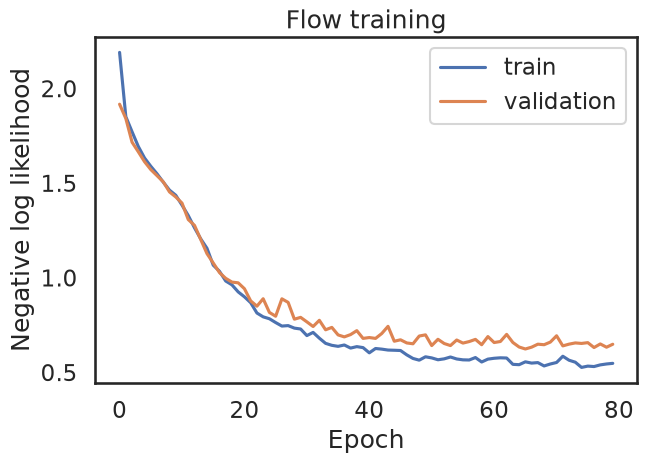

In [13]:

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(losses["train"], label="train")
ax.plot(losses["val"], label="validation")
ax.set(title="Flow training", xlabel="Epoch", ylabel="Negative log likelihood")
ax.legend();

The training and validation curves should decrease together if the flow is fitting the dataset without obvious instability.

`fit_to_data` carves its own validation split out of `X`, so to get a number nothing has been tuned against we score the independent draw we generated at the start.

In [14]:
moons_ll = float(jnp.mean(flow.log_prob(jnp.asarray(X_moons_test))))
print(f'Flow: {moons_ll:+.3f} nats on {X_moons_test.shape[0]:,} held-out points')

Flow: -0.571 nats on 2,500 held-out points


**Twelve affine layers, on a problem the affine transformer should not be able to do.**
Each layer can only stretch and shift one coordinate at a time, and the moons are curved -- yet stacking twelve of them, with a permutation between each pair, composes into a map that bends.

That is a real and slightly surprising fact about two dimensions, and it is worth stating as a hypothesis we will test rather than a rule: **depth can substitute for transformer flexibility here.**
Swapping in a rational-quadratic spline and dropping to 6 layers lands within a couple of hundredths of a nat of this number (exercise 1 below).

It will **not** hold on POWER. Six dimensions and 200,000 rows are a different regime, and exercise 7 measures exactly how much depth fails to buy there.

### Two checks on the fitted flow

The masking and the monotone transformer were supposed to guarantee a triangular Jacobian and an invertible map. The flow is trained now, so rather than take that on trust we can measure it.

1. **Round trip.** Push a batch of $z$ through $f$ and back through $f^{-1}$, and see how far it lands from where it started.
2. **Log-determinant.** FlowJAX computes $\log|\det J|$ cheaply, by summing a diagonal. Compare it against a brute-force `slogdet` of the *full* Jacobian assembled by `jax.jacfwd`, at real data points and in the direction `log_prob` actually uses ($x \to z$). If the cheap route were wrong, every likelihood in this notebook would be wrong with it.

In [15]:
key, subkey = random.split(key)
z_batch = random.normal(subkey, (512, X.shape[1]))

# 1. z -> x is the sampling direction (D sequential passes), x -> z is one pass.
x_batch = jax.vmap(flow.bijection.transform)(z_batch)
z_back  = jax.vmap(flow.bijection.inverse)(x_batch)
err = jnp.abs(z_back - z_batch)
print(f'round trip  |f^-1(f(z)) - z|       median {jnp.median(err):.0e}    max {jnp.max(err):.0e}')

# 2. The cheap log-determinant against a brute-force one, at real data points.
x_data = jnp.asarray(X[:512])
_, log_det = jax.vmap(flow.bijection.inverse_and_log_det)(x_data)
J = jax.vmap(jax.jacfwd(flow.bijection.inverse))(x_data)
sign, slogdet = jnp.linalg.slogdet(J)
gap = jnp.abs(slogdet - log_det)
print(f'log|det J|  cheap vs brute force   median {jnp.median(gap):.0e}    max {jnp.max(gap):.0e}')
print(f'determinant sign is +1 everywhere: {bool(jnp.all(sign > 0))}')

round trip  |f^-1(f(z)) - z|       median 3e-07    max 4e-03


log|det J|  cheap vs brute force   median 6e-04    max 1e-02
determinant sign is +1 everywhere: True


Both identities hold, and the **median** is the number to read: at $3 \times 10^{-7}$ the round trip is sitting on float32 machine epsilon, and the cheap log-determinant tracks the brute-force one about as closely as float32 permits.

The **maxima** are bigger -- $4\times10^{-3}$ and $10^{-2}$ across 512 points -- and it is worth being precise about what that is. It is *not* a broken bijection. Inverting this flow means undoing twelve layers in sequence, each one's output feeding the next, so rounding error compounds along the way. Re-running exactly this cell under `jax.config.update('jax_enable_x64', True)` drops the two maxima to $2\times10^{-15}$ and $1\times10^{-14}$ -- the signature of arithmetic, not of a modelling error. Exercise 4 asks you to confirm that yourself.

Float32 is still the right choice for training, where nothing depends on the seventh decimal. But if you ever need a flow's inverse to be genuinely exact -- and some uses of flows do -- this is the cell that tells you what you are actually getting.

The determinant's sign is $+1$ at every point, as it has to be: every diagonal entry is an $e^{s_j} > 0$, so the map is orientation-preserving and never folds space over onto itself.

Now we can compare all three fitted densities on the same grid.

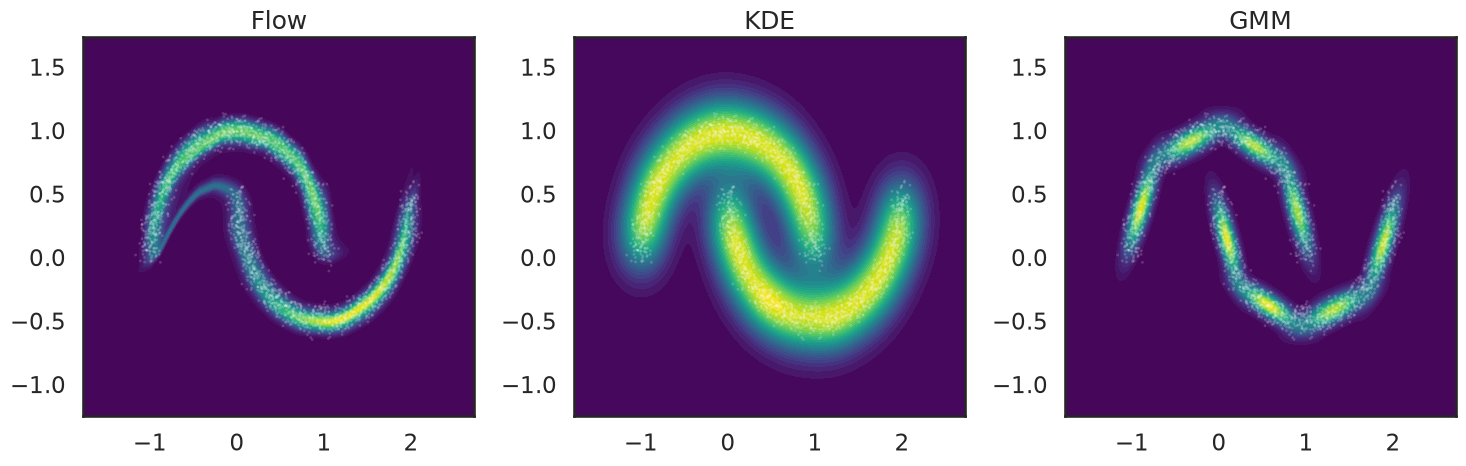

In [16]:

flow_log_density = np.asarray(flow.log_prob(jnp.asarray(grid)))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_density(xs, ys, flow_log_density, data=X, title="Flow", ax=axes[0])
plot_density(xs, ys, kde_log_density, data=X, title="KDE", ax=axes[1])
plot_density(xs, ys, gmm_log_density, data=X, title="GMM", ax=axes[2])
fig.tight_layout()


The difference is structural.
A GMM approximates the moons by mixing Gaussians -- ellipses.
A flow starts from a simple base density and learns a nonlinear invertible warp of the metric space, so it can place probability mass along curved shapes while still remaining a normalized density model.

Look closely at the flow panel and there is one faint wisp of mass trailing off the left tip of the upper crescent, into empty space.
That is the affine transformer showing its limits: twelve affine layers get very close to the right shape, but not quite all the way, and what is left over has to go somewhere.
Exercise 1 swaps in a spline, which removes it.
(At eight affine layers the same defect is not a wisp but a broad band smeared right between the two crescents -- worth trying, to see how a density model fails.)

We can also sample from the estimated densities, and here, too, the flow model is much better. So it can also be used as a generative model.

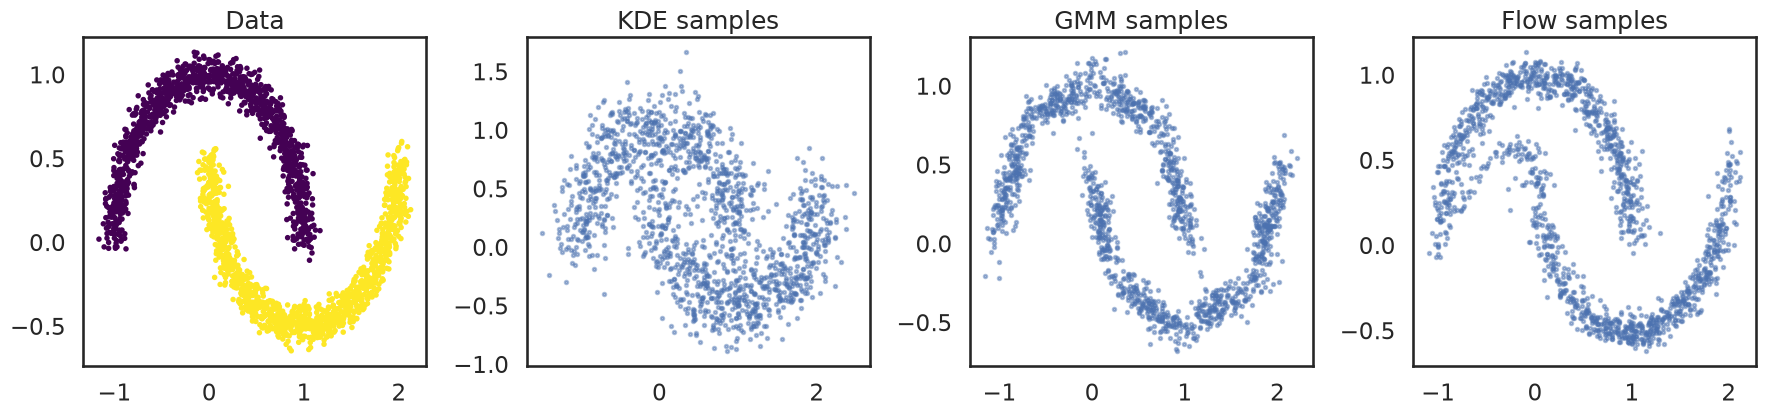

In [17]:

kde_samples = clip_to_window(kde.sample(1500, random_state=0), lower, upper)
gmm_samples, _ = gmm.sample(1500)
gmm_samples = clip_to_window(gmm_samples, lower, upper)

key, subkey = random.split(key)
flow_samples = np.asarray(flow.sample(subkey, (1500,)))
flow_samples = clip_to_window(flow_samples, lower, upper)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
axes[0].scatter(X[:, 0], X[:, 1], c=labels, s=6, cmap="viridis")
axes[0].set(title="Data")

for ax, samples, title in zip(
    axes[1:],
    [kde_samples, gmm_samples, flow_samples],
    ["KDE samples", "GMM samples", "Flow samples"],
):
    ax.scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.45)
    ax.set(title=title)
fig.tight_layout()


# A real dataset: UCI POWER

Two moons is a good place to build intuition and a bad place to draw conclusions.
In two dimensions KDE is *genuinely competitive* -- the first half of this notebook understates it, because with 2500 points on a plane, putting a small Gaussian on every point is close to optimal.

The case for flows is **dimension and sample size**:

- KDE is not really a fitted model. It stores the training set, so its memory and its scoring cost grow linearly with $n$, and in $d$ dimensions the number of points needed to fill space grows exponentially.
- A GMM is a fixed-size model, but every component is an ellipse, so matching a complicated shape means using a lot of components, and the number of components is a hyper-parameter.
- A flow is a fixed-size model with an *exact*, cheap likelihood and cheap sampling, and its cost at test time does not depend on how much data it was trained on.

To see that, we need a dataset that is neither two-dimensional nor small.

We use **POWER**, one of five benchmarks introduced by [Papamakarios, Pavlakou & Murray (2017)](https://arxiv.org/abs/1705.07057), the paper that defined MAF.
Every subsequent flow paper -- RealNVP comparisons, NAF, Block-NAF, Neural Spline Flows, FFJORD, Glow -- reports the same five numbers, so the published table gives us something to measure ourselves against.

POWER is derived from the UCI *Individual household electric power consumption* dataset: about two million minute-by-minute readings from one French household over four years, reduced to six dimensions.
Six dimensions is small enough that we can still look at every pairwise marginal, and large enough that KDE starts to hurt.

## Loading and preprocessing

We use Papamakarios's preprocessed archive (Zenodo record [1161203](https://zenodo.org/records/1161203), CC-BY-4.0), which is what the whole comparison literature uses. Fetch it once with

```
python download_data.py maf-benchmarks
```

The file has eight columns; the paper's Appendix D reduces them to six:

| # | column | kept? | why |
|---|---|---|---|
| 0 | global active power (kW) | ✔ | |
| 1 | global reactive power (kW) | ✘ | 23.5% of the values are exactly zero -- a discrete-valued attribute |
| 2 | voltage (V) | ✔ | |
| 3 | global intensity (A) | ✘ | Pearson $\rho = 0.999$ with global active power -- almost perfectly redundant |
| 4 | sub-metering 1 (Wh, kitchen) | ✔ | |
| 5 | sub-metering 2 (Wh, laundry) | ✔ | |
| 6 | sub-metering 3 (Wh, water heater and AC) | ✔ | |
| 7 | time of day (minutes past midnight) | ✔ | |

A near-perfectly correlated column is not just redundant: a continuous density on a set of measure zero is infinite, so a model that finds the relationship exactly gets an unbounded likelihood.
The same problem, in milder form, is why we have to *dequantize*.

In [18]:
def load_power(path='../data/maf/power/data.npy', seed=42):
    """UCI POWER, preprocessed as in Papamakarios et al. (2017), Appendix D."""
    rng = np.random.RandomState(seed)
    data = np.load(path)
    rng.shuffle(data)
    n = data.shape[0]

    # Drop global intensity (rho = 0.999 with active power) and then global
    # reactive power (23.5% exact zeros). Order matters: index 3 before index 1.
    data = np.delete(data, 3, axis=1)
    data = np.delete(data, 1, axis=1)

    # --- Dequantization. This is NOT optional. -------------------------------
    # The meters report rounded values: active power to 0.001 kW, voltage to
    # 0.01 V, and the three sub-meterings to whole watt-hours. A continuous
    # density fitted to values that only ever land on a lattice can pile up
    # arbitrarily tall spikes on that lattice, and the log-likelihood then runs
    # off to +infinity -- the model looks wonderful and has learned nothing.
    # Adding uniform noise of exactly one quantization step spreads each
    # reported value over the interval it actually stands for.
    # Time of day is already continuous in this file, so it gets no noise.
    data = data + np.hstack([
        0.001 * rng.rand(n, 1),   # global active power
        0.01 * rng.rand(n, 1),    # voltage
        rng.rand(n, 3),           # sub-metering 1, 2, 3
        np.zeros((n, 1)),         # time of day
    ])
    # -------------------------------------------------------------------------

    n_test = int(0.1 * n)                       # 10% test
    test, rest = data[-n_test:], data[:-n_test]
    n_val = int(0.1 * rest.shape[0])            # 10% of the rest for validation
    val, train = rest[-n_val:], rest[:-n_val]

    # Standardize using train + validation only.
    ref = np.vstack([train, val])
    mu, sd = ref.mean(axis=0), ref.std(axis=0)
    return (train - mu) / sd, (val - mu) / sd, (test - mu) / sd


POWER_COLUMNS = ['active power', 'voltage', 'sub-meter 1',
                 'sub-meter 2', 'sub-meter 3', 'time of day']

power_train, power_val, power_test = load_power()
print('train', power_train.shape, 'validation', power_val.shape, 'test', power_test.shape)

train (1659917, 6) validation (184435, 6) test (204928, 6)


Two million rows and six columns, split 1,659,917 / 184,435 / 204,928.

Let us look at the pairwise marginals. This is the six-dimensional version of the scatter plot we drew for the moons, and it is the last point at which we can *see* the distribution we are about to model.

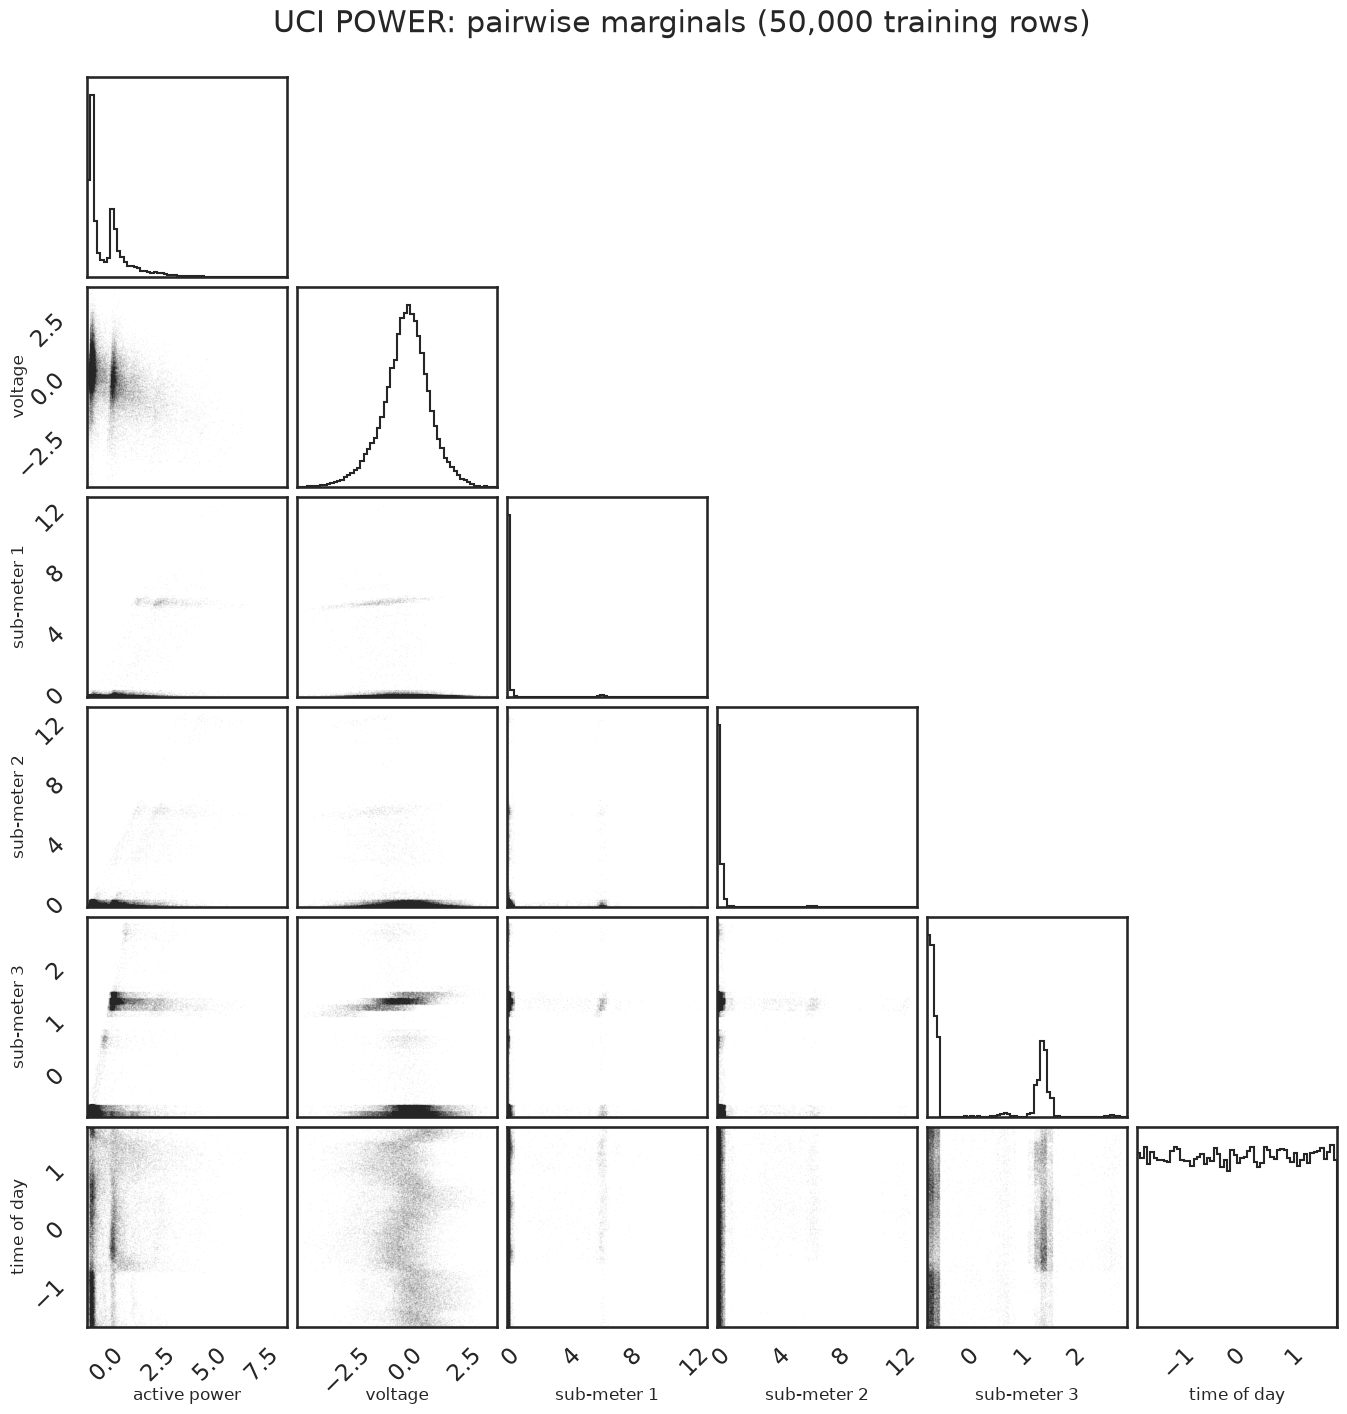

In [19]:
import corner

fig = corner.corner(
    power_train[:50_000],
    labels=POWER_COLUMNS,
    bins=60,
    max_n_ticks=4,
    plot_contours=False,
    plot_density=False,
    data_kwargs=dict(alpha=0.03, ms=1),
    label_kwargs=dict(fontsize=12),
)
fig.suptitle('UCI POWER: pairwise marginals (50,000 training rows)', y=1.02);

Nothing here is Gaussian.
The sub-meterings are spikes at zero with long thin tails -- most minutes, the kitchen is simply off.
Time of day is close to uniform by construction.
Active power is skewed and strongly coupled to time of day and to the sub-meterings.
A single Gaussian has no chance, and it is not obvious that a handful of ellipses will do much better.

## Subsampling, and why all four models see the same data

We fit every model on the same 200,000 training rows, a random subsample of the 1.66M available.

That is a deliberate handicap on the flow, which is happy with all 1.66M rows and trains on them in about four minutes on a GPU. 
The reason is comparability: KDE stores its training set and scores in $O(n_\text{train} \times n_\text{test})$, so at 1.66M rows it cannot be scored at all within a class. Giving all four models the same 200k rows keeps this an apples-to-apples comparison instead of a comparison of budgets.

We come back at the end to what the flow does when the handicap is removed.

In [20]:
N_TRAIN = 200_000

rng = np.random.default_rng(SEED)
X_train = power_train[rng.choice(power_train.shape[0], N_TRAIN, replace=False)].astype(np.float32)
X_validation = power_val[:20_000].astype(np.float32)
X_test = power_test.astype(np.float32)
print(X_train.shape, X_validation.shape, X_test.shape)

(200000, 6) (20000, 6) (204928, 6)


## Baseline 1: a single Gaussian

The MAF paper reports a full-covariance Gaussian as its own floor, so we can check our preprocessing against a published number before doing anything clever.

We report the **average test log-likelihood in nats per data point** (higher is better; nat=natural lograithm), summed over the six dimensions. Higher is better, and because the data is standardized rather than bounded, the numbers can be positive: a density can exceed 1.

In [21]:
def gaussian_log_likelihood(train, test):
    mean = train.mean(axis=0)
    cov = np.cov(train, rowvar=False)
    _, logdet = np.linalg.slogdet(cov)
    precision = np.linalg.inv(cov)
    delta = test - mean
    quadratic = np.einsum('ij,jk,ik->i', delta, precision, delta)
    return -0.5 * (quadratic + logdet + test.shape[1] * np.log(2 * np.pi))

t0 = time.time()
gaussian_ll = gaussian_log_likelihood(X_train, X_test).mean()
print(f'Gaussian: {gaussian_ll:.3f} nats  ({time.time() - t0:.1f}s)')

Gaussian: -7.742 nats  (0.0s)


−7.74 nats, which is exactly the figure in Table 1 of the MAF paper. The preprocessing is right.

## Baseline 2: Gaussian mixtures

A GMM is the natural next step: still ellipses, but several of them. How many do we need? We sweep the number of components and choose on the validation set.

In [22]:
gmm_results = {}
for n_components in (5, 10, 20, 50):
    t0 = time.time()
    gmm = GaussianMixture(n_components=n_components, covariance_type='full',
                          random_state=SEED, max_iter=200).fit(X_train)
    gmm_results[n_components] = dict(
        validation=gmm.score(X_validation), test=gmm.score(X_test),
        seconds=time.time() - t0, model=gmm)
    r = gmm_results[n_components]
    print(f'GMM {n_components:>3} components: '
          f'validation {r["validation"]:+.3f}  test {r["test"]:+.3f} nats  '
          f'({r["seconds"]:.0f}s)')

best_k = max(gmm_results, key=lambda k: gmm_results[k]['validation'])
gmm_ll = gmm_results[best_k]['test']
print(f'\nbest on validation: {best_k} components, {gmm_ll:+.3f} nats on test')

GMM   5 components: validation -1.188  test -1.200 nats  (3s)


GMM  10 components: validation -0.814  test -0.822 nats  (3s)


GMM  20 components: validation -0.381  test -0.391 nats  (10s)


GMM  50 components: validation -0.114  test -0.123 nats  (33s)

best on validation: 50 components, -0.123 nats on test


The mixture never stops improving -- and never stops getting more expensive, because a full covariance in six dimensions is 21 free parameters plus a mean plus a weight for every component.
We measured 100 components as well: **+0.014 nats, 94 seconds to fit**. Still climbing, still behind where the flow will land.

## Baseline 3: KDE, and the reason we have to cheat to score it

KDE has no fitting (`fit` just stores the array) so the whole cost is at scoring time, and it is $O(n_\text{train} \times n_\text{test})$.

Our test set has 204,928 points and our training set has 200,000. That is $4 \times 10^{10}$ kernel evaluations for one number, which will not finish inside a lesson.
**So we score KDE on a fixed random subsample of 5,000 test points and say so.**

Note which way that biases the comparison: it makes KDE look *cheaper* than it is, so the timing below is a lower bound on the real cost. The argument against KDE survives the concession.

In [23]:
N_KDE_TEST = 5_000
# Its own generator, so re-running this cell always scores the same points.
kde_test = X_test[np.random.default_rng(SEED + 1).choice(X_test.shape[0], N_KDE_TEST, replace=False)]

# Bandwidth swept over 0.05 ... 0.3 on a validation subsample. The optimum is
# flat between 0.07 and 0.09, so we use 0.08.
t0 = time.time()
power_kde = KernelDensity(kernel='gaussian', bandwidth=0.08).fit(X_train)
kde_fit_seconds = time.time() - t0

t0 = time.time()
kde_ll = power_kde.score_samples(kde_test).mean()
kde_score_seconds = time.time() - t0

print(f'KDE: {kde_ll:+.3f} nats on a {N_KDE_TEST}-point test subsample')
print(f'     fit {kde_fit_seconds:.1f}s + score {kde_score_seconds:.1f}s '
      f'= {kde_fit_seconds + kde_score_seconds:.1f}s')
print(f'     scoring the full {X_test.shape[0]:,} test points would take about '
      f'{kde_score_seconds * X_test.shape[0] / N_KDE_TEST / 60:.0f} minutes')

KDE: -0.783 nats on a 5000-point test subsample
     fit 0.2s + score 32.8s = 32.9s
     scoring the full 204,928 test points would take about 22 minutes


## The flow

The *structure* carries over from the moons untouched -- masked autoregressive, MADE conditioners, the same `fit_to_data` call -- and that is the point: a flow is a **density model**, not a per-dataset construction. Four things change.

1. **Six input dimensions** instead of two.
2. **More capacity**: 8 layers and `nn_width=128`.
3. **A different transformer.** We replace the affine map with a **rational-quadratic spline** ([Durkan, Bekasov, Murray & Papamakarios, 2019](https://arxiv.org/abs/1906.04032)): a monotone, piecewise-rational function pinned together at `knots` control points. It is still strictly monotone, so the layer is still invertible, and it still has a closed-form derivative and inverse, so the log-determinant is still just the sum of the diagonal — nothing about the structure has to change to accommodate it. What it buys is *bending*: an affine transformer can only stretch and shift its dimension, a spline can curve it. We will not derive it; for our purposes it is a drop-in, more flexible replacement for `Affine()`.
4. **A wider spline `interval`.** A rational-quadratic spline is defined on a box $[-B, B]$ and is pinned to the identity outside it, so $B$ has to be set against the scale of the data. Standardized POWER runs out past $\pm 8$, which is why `interval` is 5 here rather than the 4 used on the moons in the exercises below.

With the transformer swapped this is no longer a MAF in the paper's sense: the *structure* is the paper's, the *transformer* is two years newer. Keep that distinction in mind when we compare against published numbers.

In [24]:
key = random.key(SEED)

key, subkey = random.split(key)
power_flow = flowjax.flows.masked_autoregressive_flow(
    subkey,
    base_dist=flowjax.distributions.Normal(jnp.zeros(X_train.shape[1])),
    transformer=flowjax.bijections.RationalQuadraticSpline(knots=8, interval=5),
    flow_layers=8,
    nn_width=128,
    nn_depth=2,
)

Training is the same call as before (higher learning rate).
On the two moons it took a couple of seconds; here, on 200,000 six-dimensional rows, it takes under a minute on a GPU -- short enough to run live in class, so there is no checkpoint to reload.

In [25]:
t0 = time.time()
key, subkey = random.split(key)
power_flow, power_losses = flowjax.train.fit_to_data(
    subkey,
    power_flow,
    jnp.asarray(X_train),
    learning_rate=1e-3,
    batch_size=1024,
    max_patience=5,
    max_epochs=50,
    show_progress=True,
)
flow_train_seconds = time.time() - t0
print(f'\ntrained for {len(power_losses["train"])} epochs in {flow_train_seconds:.0f}s')

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:07<?, ?it/s, train=1.29, val=0.509]

  2%|▏         | 1/50 [00:07<06:01,  7.37s/it, train=1.29, val=0.509]

  2%|▏         | 1/50 [00:08<06:01,  7.37s/it, train=0.418, val=0.229]

  4%|▍         | 2/50 [00:08<02:46,  3.46s/it, train=0.418, val=0.229]

...

 74%|███████▍  | 37/50 [00:34<00:09,  1.32it/s, train=-0.344, val=-0.348]

 74%|███████▍  | 37/50 [00:34<00:09,  1.32it/s, train=-0.355, val=-0.355]

 74%|███████▍  | 37/50 [00:34<00:09,  1.32it/s, train=-0.355, val=-0.355 (Max patience reached)]

 74%|███████▍  | 37/50 [00:34<00:12,  1.06it/s, train=-0.355, val=-0.355 (Max patience reached)]


trained for 38 epochs in 36s


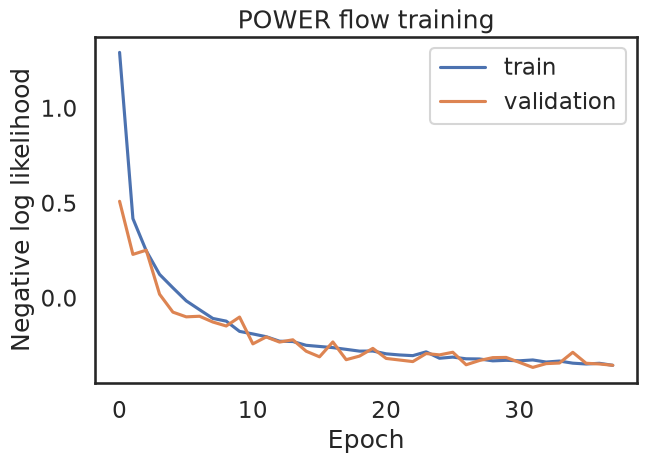

In [26]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(power_losses['train'], label='train')
ax.plot(power_losses['val'], label='validation')
ax.set(title='POWER flow training', xlabel='Epoch', ylabel='Negative log likelihood')
ax.legend();

`fit_to_data` holds out 10% of what we give it as its own validation split and stops when that stops improving, so the curve ends by itself rather than at `max_epochs`.

Now score the flow on the **full** test set -- which we can do, because unlike KDE its cost does not depend on the size of the training set.

In [27]:
t0 = time.time()
flow_ll = np.concatenate([
    np.asarray(power_flow.log_prob(jnp.asarray(X_test[i:i + 50_000])))
    for i in range(0, X_test.shape[0], 50_000)
]).mean()
flow_score_seconds = time.time() - t0
print(f'Flow: {flow_ll:+.3f} nats on all {X_test.shape[0]:,} test points '
      f'({flow_score_seconds:.1f}s)')

Flow: +0.337 nats on all 204,928 test points (7.7s)


Eight seconds for 204,928 points, against KDE's estimated 22 minutes for the same job.

All four models, side by side:

In [28]:
print(f'{"model":<48}{"test log-likelihood":>22}   scored on')
print('-' * 92)
for name, ll, n in [
    ('Gaussian', gaussian_ll, X_test.shape[0]),
    (f'GMM ({best_k} components)', gmm_ll, X_test.shape[0]),
    ('KDE (bandwidth 0.08)', kde_ll, N_KDE_TEST),
    ('Masked autoregressive flow (spline transformer)', flow_ll, X_test.shape[0]),
]:
    print(f'{name:<48}{ll:>+15.3f} nats   {n:,} points')

model                                              test log-likelihood   scored on
--------------------------------------------------------------------------------------------
Gaussian                                                 -7.742 nats   204,928 points
GMM (50 components)                                      -0.123 nats   204,928 points
KDE (bandwidth 0.08)                                     -0.783 nats   5,000 points
Masked autoregressive flow (spline transformer)          +0.337 nats   204,928 points


## Do the samples look like the data?

A log-likelihood is one number. The other half of what a flow gives us is sampling, so we can draw from the fitted model and put its marginals next to the data's.

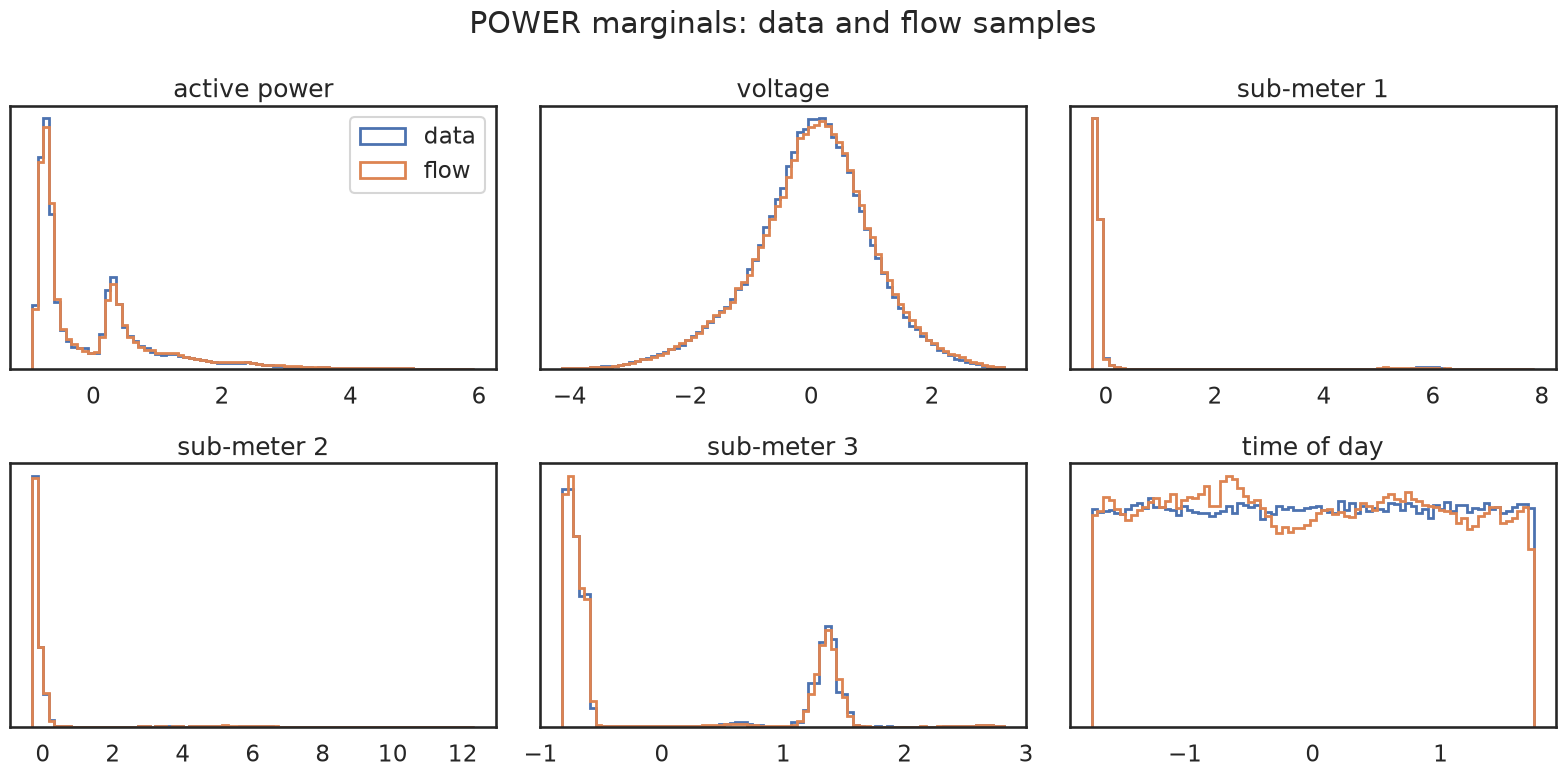

In [29]:
key, subkey = random.split(key)
power_samples = np.asarray(power_flow.sample(subkey, (200_000,)))

# 1D marginals: data against flow samples, one panel per dimension
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, j, name in zip(axes.ravel(), range(6), POWER_COLUMNS):
    lo, hi = np.percentile(X_train[:, j], [0.05, 99.95])
    bins = np.linspace(lo, hi, 80)
    ax.hist(X_train[:, j], bins=bins, density=True, histtype='step', lw=2, label='data')
    ax.hist(power_samples[:, j], bins=bins, density=True, histtype='step', lw=2, label='flow')
    ax.set(title=name, yticks=[])
axes[0, 0].legend()
fig.suptitle('POWER marginals: data and flow samples')
fig.tight_layout()

Every marginal lines up, including the spike-at-zero sub-meterings that no Gaussian mixture would get right.

But matching all six marginals is necessary, not sufficient -- a model that got the dependence structure completely wrong could still do that. So we also compare a joint: active power against time of day, the most structured panel in the corner plot above.

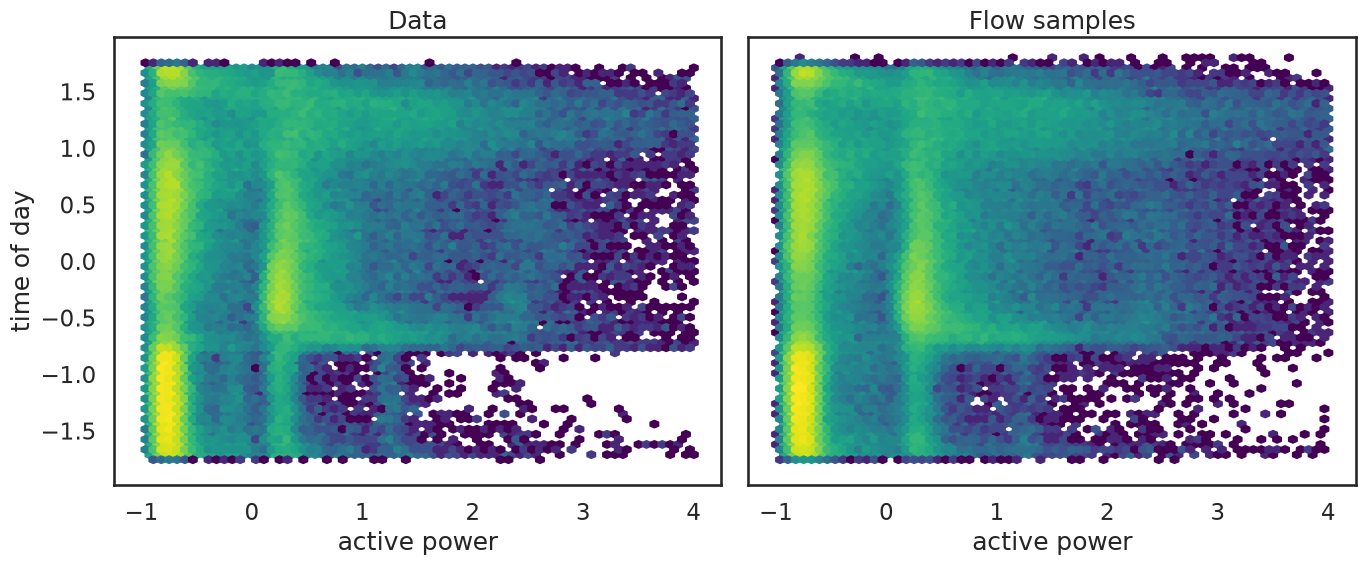

In [30]:
# The marginals can match while the joint structure does not, so look at a pair.
# Active power against time of day is the most structured panel in the corner plot.
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, data, title in zip(axes, [X_train, power_samples], ['Data', 'Flow samples']):
    ax.hexbin(data[:, 0], data[:, 5], gridsize=70, bins='log',
              extent=(-1, 4, -1.8, 1.8), cmap='viridis')
    ax.set(title=title, xlabel=POWER_COLUMNS[0])
axes[0].set_ylabel(POWER_COLUMNS[5])
fig.tight_layout()

## What the numbers mean

Our four numbers are in the table above. The published POWER numbers come from **Table 1** of the MAF paper ([Papamakarios, Pavlakou & Murray, 2017](https://arxiv.org/abs/1705.07057)) -- *average test log likelihood in nats for unconditional density estimation*, on the same preprocessing and the **full** 1.66M-row training set. Models are rows and datasets are columns, so POWER is one column; here it is, in full:

| model | POWER |
|---|---|
| Gaussian | −7.74 ± 0.02 |
| MADE | −3.08 ± 0.03 |
| MADE MoG | **0.40 ± 0.01** |
| Real NVP (5) | −0.02 ± 0.01 |
| Real NVP (10) | 0.17 ± 0.01 |
| MAF (5) | 0.14 ± 0.01 |
| MAF (10) | 0.24 ± 0.01 |
| MAF MoG (5) | 0.30 ± 0.01 |

The error bars are **two** standard deviations, not one. The numbers in parentheses are the number of layers.

Two things to notice before comparing ourselves to any of it.

**Our Gaussian baseline reproduces theirs exactly.** They report −7.74 ± 0.02; we measured −7.742, from our own `load_power`. Since that number is a deterministic function of the preprocessing -- which columns are dropped, how the dequantization noise is scaled, how the standardization is computed -- hitting it is a real check that we are modelling the same distribution they were, and not a coincidence. Everything below is only meaningful because this line matches.

**MADE MoG beats every MAF variant on POWER.** 0.40 against MAF (10)'s 0.24. POWER is the MAF's *weakest* column of the five, so of all the benchmarks this is the least flattering place to have picked. That is worth knowing before reading anything triumphal into our own result.

### Where our number sits, honestly

We measured **+0.337**. It is *not* a reproduction of any row in that table, and the deviations run in **both** directions, so it cannot be read as beating or failing to reach anything.

Pushing our number **down**, relative to a published MAF:

- 200,000 training rows instead of 1,659,917;
- 8 layers rather than 10;
- no hyperparameter search at all;
- no batch normalization between layers, which the original MAF used and FlowJAX's `masked_autoregressive_flow` does not.

Pushing our number **up**:

- a rational-quadratic spline transformer, which is strictly more expressive than the affine transformer a MAF uses, and postdates the paper by two years.

Landing at +0.337 -- between MAF (10) at 0.24 and MAF-DDSF (5) at 0.62 -- is roughly where a spline flow *ought* to sit. But with handicaps in both directions and no ablation separating them, that agreement is reassuring rather than evidential. We are not reproducing MAF; we are running a different model on less data with less tuning, and getting a plausible number.

The 0.62 figure is **MAF-DDSF (5)** from Table 2 of [Huang, Krueger, Lacoste & Courville (2018)](https://arxiv.org/abs/1804.00779), *Neural Autoregressive Flows* -- a different paper from the MAF one, and there is no row in it labelled simply "NAF"; the NAF results appear under the MAF-DDSF designations.

Expect your own run to differ in the second decimal, and do not be surprised if it differs from the number printed above. Running this notebook three times on the same GPU, with the same seed and the same code, scored **+0.337, +0.350 and +0.368**, stopping at 38, 38 and 46 epochs. GPU reductions are not bit-deterministic, so the optimization drifts onto a slightly different trajectory each time; early stopping then fires at a different epoch, and a different epoch is a different model -- though note that the two 38-epoch runs still disagreed, so the epoch count is not the whole story. The full spread is about 0.03 nats. That is far smaller than any difference we draw a conclusion from here, and much smaller than the 0.13 nats we are about to recover by lifting the subsample -- but it is worth knowing before you chase a hundredth of a nat, and it is the reason this notebook quotes orderings rather than exact values.

**Removing the handicap helps, and it is cheap.** We trained the identical flow on all 1,659,917 training rows: **0.477 nats in 244 seconds**. So roughly another 0.13 nats is sitting in the subsample we imposed for KDE's benefit. KDE cannot take that trade -- we measured its fit-and-score time on 5,000 test points as 4.9 s, 9.2 s, 16.9 s and 33.0 s for 25k, 50k, 100k and 200k training rows, which is exactly the linear growth the $O(n_\text{train} \times n_\text{test})$ cost predicts. At 1.66M rows it would take about four and a half minutes to score 5,000 points, and about three hours to score the test set the flow scores in eight seconds.

**Ordering matters more than the exact values.** The Gaussian is 7.4 nats behind everything else; that is the cost of assuming one ellipse. KDE, which was competitive on the moons, is now *worse than a 20-component GMM* -- in six dimensions its local kernels no longer have enough neighbours to average over. And the flow beats a 100-component GMM while being a fixed-size model you can sample from in one pass.

Across the five MAF benchmarks the original paper found MAF best on three and MADE MoG best on the other two -- and POWER, as the table above shows, is one of those two. No single density model wins everywhere. What generalizes is the shape of the argument: as $d$ and $n$ grow, models that *store* data lose to models that *compress* it into a map.

### Where the three model families sit

- An **autoencoder** learns a representation. It has no density and cannot tell you how probable a point is -- it is not a generative model.
- A **normalizing flow** learns a density you can both evaluate exactly and sample from, at the price of invertibility, which constrains the architecture.
- A **GAN** learns to sample without ever writing down a density.

Normalizing flows also have a second classical use we do not demonstrate here: [Rezende & Mohamed (2015)](https://arxiv.org/abs/1505.05770) named them and used them to make variational posteriors more flexible in variational inference.

## Exercises

**On the two moons**

1. **Spline instead of depth.** Swap `flowjax.bijections.Affine()` for `flowjax.bijections.RationalQuadraticSpline(knots=8, interval=4)` and drop `flow_layers` from 12 to 6, leaving everything else alone. Score it on `X_moons_test`. You should land around **−0.56**, i.e. no better than the 12 affine layers, with half the layers. Why can depth stand in for transformer flexibility here? (Think about what a *composition* of affine maps with permutations between them can do in two dimensions.)
2. **Budget.** Change `flow_layers`, `nn_width` and `nn_depth` one at a time from the 12 / 64 / 2 we used, and compare the held-out likelihood and the density plot. Which of the three buys the most per unit of training time? Watch for the point where more capacity stops helping -- `fit_to_data` early-stops, so an over-large flow shows up as a flat validation curve rather than as a blow-up.
3. Increase or decrease the KDE bandwidth and compare the density heatmap. How wrong does it have to be before the moons stop being visible?

4. **How invertible is it, really?** Put `jax.config.update('jax_enable_x64', True)` at the very top of the notebook, restart the kernel, and re-run the round-trip and log-determinant checks above. Both maxima should collapse to around $10^{-15}$, confirming that the float32 spread is compounded rounding error and not a defect in the map. Then reduce `flow_layers` from 12 to 3, back in float32, and watch the maximum shrink -- the error compounds with depth, which is the price of inverting a deep flow one layer at a time.

**On POWER**

5. **Drop the dequantization noise.** Comment out the `data + np.hstack([...])` step in `load_power` and refit the flow. Watch the training log-likelihood climb past anything the model deserves, and explain in one sentence what the flow is actually doing to the discrete sub-metering values. This is the single most important failure mode in this notebook.
6. **Measure the crossover.** Plot KDE's fit-and-score time and the flow's train-and-score time against training-set size, for 25k, 50k, 100k and 200k rows, holding the test set fixed at 5,000 points. One of the two curves is linear in $n_\text{train}$ and the other is roughly flat. Where would they cross if you extrapolated to the full 1.66M rows?
7. **Depth instead of a spline -- the same trade, six dimensions on.** Swap the `RationalQuadraticSpline` for `flowjax.bijections.Affine()` in the POWER flow, at `flow_layers=8` and again at 12, and score on the full test set. Expect roughly **+0.04** and **+0.11**, against the spline's **+0.35**.

   So depth does *not* substitute for the transformer here, although it did on the moons in exercise 1. What changed? Two things are worth separating in your answer: the dimension, and how much structure a single affine layer can express once there are six coordinates to permute among rather than two.

   Two warnings before you read too much into the numbers. At 8 layers the `max_epochs=50` cap is **binding** -- affine-8 has not converged, so +0.04 is a lower bound under this notebook's budget, not the model's ceiling. And going to 16 layers is not the fix: it reaches about +0.13 but diverges late in training on most seeds, which you will see as a spike near the end of the loss curve (`fit_to_data` returns the best parameters, so the reported score survives, but the model was not stable).

**On a harder dataset**

8. **MINIBOONE.** `data/maf/miniboone/data.npy` is 36,488 rows in 43 dimensions -- the smallest of the five MAF benchmarks and the highest-dimensional one we downloaded. Split and standardize it the same way, then fit the Gaussian, a GMM and the flow. (Skip KDE, or score it on a few hundred points.) The published MAF(5) number is 11.75 nats against a Gaussian baseline of −37.24. This is where the classical baselines stop being competitive at all -- with 43 dimensions and 30,000 rows there is simply nothing local for a kernel to average over.

# References

1. Germain, Gregor, Murray & Larochelle (2015), [*MADE: Masked Autoencoder for Distribution Estimation*](https://arxiv.org/abs/1502.03509), ICML. The masking scheme that gives all $D$ autoregressive conditioners out of one network; it is the conditioner inside every layer of our flow.
2. Papamakarios, Pavlakou & Murray (2017), [*Masked Autoregressive Flow for Density Estimation*](https://arxiv.org/abs/1705.07057), NeurIPS. Introduced the MAF -- MADE conditioners with an affine transformer -- and the five benchmark datasets. **Table 1** (unconditional density estimation) is the source of the published POWER column quoted above; Table 2 in that paper is the *conditional* one and covers only MNIST and CIFAR-10.
3. Durkan, Bekasov, Murray & Papamakarios (2019), [*Neural Spline Flows*](https://arxiv.org/abs/1906.04032), NeurIPS. The rational-quadratic spline transformer this notebook uses on POWER.
4. Huang, Krueger, Lacoste & Courville (2018), [*Neural Autoregressive Flows*](https://arxiv.org/abs/1804.00779), ICML. Source of the 0.62 POWER figure quoted above, which is their **MAF-DDSF (5)** row in Table 2.
5. Papamakarios, Nalisnick, Rezende, Mohamed & Lakshminarayanan (2021), [*Normalizing Flows for Probabilistic Modeling and Inference*](https://jmlr.org/papers/v22/19-1028.html), JMLR 22(57). The review to read next.
6. Rezende & Mohamed (2015), [*Variational Inference with Normalizing Flows*](https://arxiv.org/abs/1505.05770), ICML. Named normalizing flows, and used them for variational inference rather than density estimation.
7. [FlowJAX documentation](https://danielward27.github.io/flowjax/).
8. Kevin P. Murphy, *Probabilistic Machine Learning: An Introduction*, chapter 23.
9. The POWER and MINIBOONE data are Papamakarios's preprocessed archive, [Zenodo record 1161203](https://zenodo.org/records/1161203) (CC-BY-4.0); POWER derives from the UCI [Individual household electric power consumption](https://archive.ics.uci.edu/dataset/235/) dataset.

# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).

This work is licensed under a CC BY-NC-SA 4.0 International License.

![Python logo](https://www.python.org/static/community_logos/python-logo.png)